# Homework 3

In [ ]:
!pip install pingouin
import pandas as pd
from scipy import stats
import pingouin as pg
from scipy.stats import pointbiserialr
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Analysis/Data_MASQLong.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Task 1


**Analyze two variables:**

1) Extra_T1

2) MASQAN_sum_T1

## Column analysis

In [ ]:
summary_stats = df[['Extra_T1', 'MASQAN_sum_T1']].describe()

summary_stats.loc['dtype'] = [df['Extra_T1'].dtype, df['MASQAN_sum_T1'].dtype]

print(summary_stats)

       Extra_T1 MASQAN_sum_T1
count     231.0         231.0
mean   3.240789      17.65368
std     0.52647      8.215652
min     1.51389           9.0
25%     2.94911          11.0
50%     3.23611          15.0
75%      3.6125          21.0
max     4.73611          47.0
dtype   float64         int64


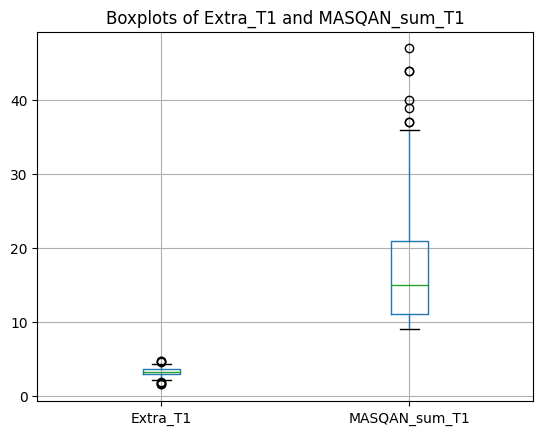

In [ ]:
df[['Extra_T1', 'MASQAN_sum_T1']].boxplot()
plt.title('Boxplots of Extra_T1 and MASQAN_sum_T1')
plt.show()



---



## Normality tests for 'Extra_T1'

**H0:** The distribution of Extra_T1 variable is not different from the normal distribution

**H1:** The distribution of Extra_T1 is different from the normal distribution

In [ ]:
column_name = 'Extra_T1'

kstest_result = stats.kstest(df[column_name].dropna(), 'norm', args=(df[column_name].dropna().mean(), df[column_name].dropna().std()))
p_value = kstest_result.pvalue

print(kstest_result)

KstestResult(statistic=0.046657704773423514, pvalue=0.6781369656606676, statistic_location=2.88589, statistic_sign=-1)


<Axes: xlabel='Extra_T1', ylabel='Density'>

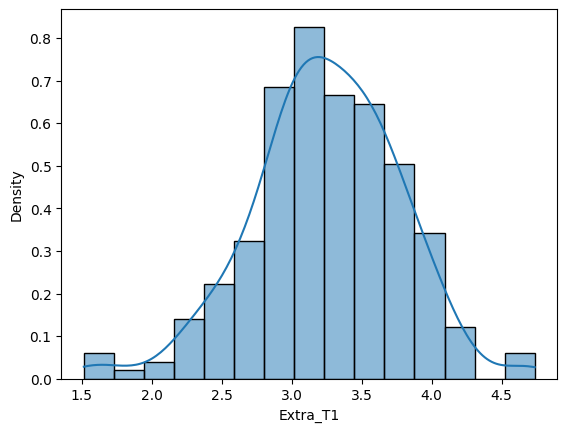

In [ ]:
sns.histplot(df['Extra_T1'].dropna(), kde=True, stat="density")

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

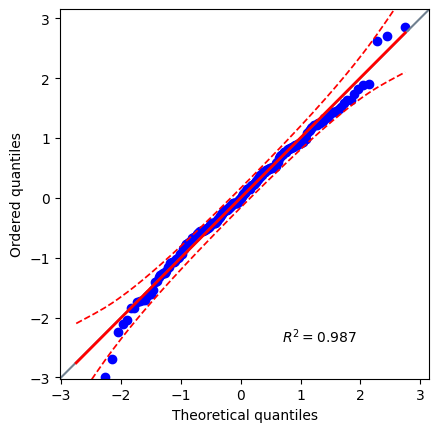

In [ ]:
pg.qqplot(df['Extra_T1'], dist = 'norm')

In [ ]:
if p_value < 0.05:
    print(f"Conclusion: p-value = {p_value} => as p-value < 0.05, H1 is accepted => the distribution is significantly different from normal")
else:
    print(f"Conclusion: p-value = {p_value} => as p-value > 0.05, H1 is rejected => the distribution is not significantly different from normal")

Conclusion: p-value = 0.6781369656606676 => as p-value > 0.05, H1 is rejected => the distribution is not significantly different from normal


## Normality tests for 'MASQAN_sum_T1'

**H0:** The distribution of MASQAN_sum_T1 variable is not different from the normal distribution

**H1:** The distribution of MASQAN_sum_T1 is different from the normal distribution

In [ ]:
column_name = 'MASQAN_sum_T1'

kstest_result = stats.kstest(df[column_name].dropna(), 'norm', args=(df[column_name].dropna().mean(), df[column_name].dropna().std()))
p_value = kstest_result.pvalue

print(kstest_result)

KstestResult(statistic=0.18538810161894448, pvalue=2.013838378838314e-07, statistic_location=17, statistic_sign=1)


<Axes: xlabel='MASQAN_sum_T1', ylabel='Density'>

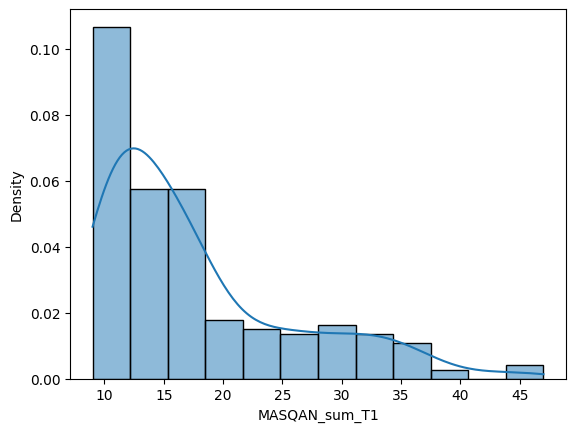

In [ ]:
sns.histplot(df['MASQAN_sum_T1'].dropna(), kde=True, stat="density")

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

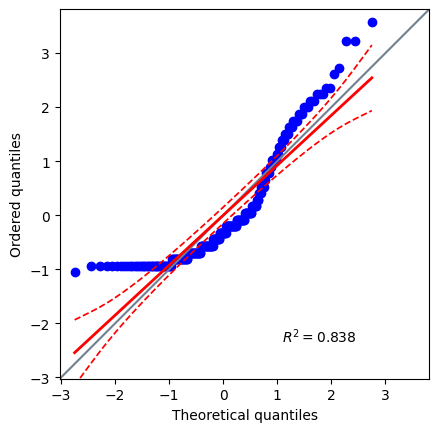

In [ ]:
pg.qqplot(df['MASQAN_sum_T1'], dist = 'norm')

In [ ]:
if p_value < 0.05:
    print(f"Conclusion: p-value = {p_value} => as p-value < 0.05, H1 is accepted => the distribution is significantly different from normal")
else:
    print(f"Conclusion: p-value = {p_value} => as p-value > 0.05, H1 is rejected => the distribution is not significantly different from normal")

Conclusion: p-value = 2.013838378838314e-07 => as p-value < 0.05, H1 is accepted => the distribution is significantly different from normal


## Correlation Analysis

<Axes: xlabel='Extra_T1', ylabel='MASQAN_sum_T1'>

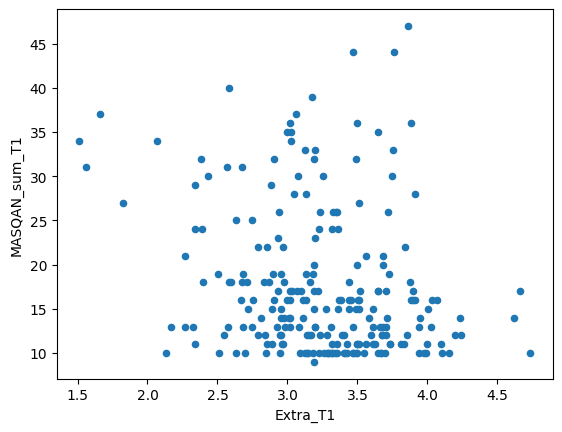

In [ ]:
df.plot('Extra_T1', 'MASQAN_sum_T1', kind='scatter')

In [ ]:
df1 = df.dropna(subset=['Extra_T1', 'MASQAN_sum_T1'])
stats.kendalltau(df1['Extra_T1'], df1['MASQAN_sum_T1'])

SignificanceResult(statistic=-0.1522051765375234, pvalue=0.0008381422419666138)

# Task 2

**Select appropriate tests to check if there is a difference in values of each variable in the following groups:**
* People with and without mental health disorder diagnosis (MH_Diag_T1)
* Males and females (Gender)
* People of different age groups (Age_T1_group)

## People with and without mental health disorder diagnosis (MH_Diag_T1)

### Kolmogorov-Smirnov test
Since the sample size for each variable under consideration exceeds 50, the Kolmogorov-Smirnov test will be used to conduct a normality test

In [ ]:
column_name = 'MASQDG_mean_T1'

kstest_result = stats.kstest(df[column_name].dropna(), 'norm', args=(df[column_name].dropna().mean(), df[column_name].dropna().std()))
p_value = kstest_result.pvalue

print(kstest_result)

KstestResult(statistic=0.14899970990434186, pvalue=6.098558695948694e-05, statistic_location=1.625, statistic_sign=1)


<Axes: xlabel='MASQDG_mean_T1', ylabel='Density'>

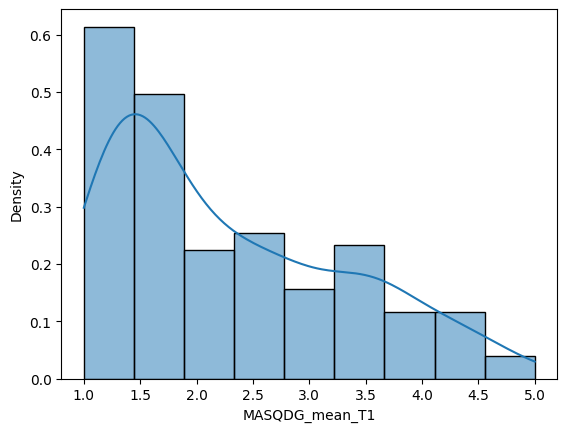

In [ ]:
import seaborn as sns
from scipy.stats import norm
sns.histplot(df['MASQDG_mean_T1'].dropna(), kde=True, stat="density")

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

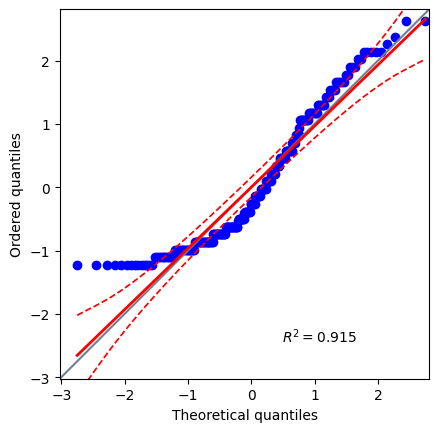

In [ ]:
import pingouin as pg
pg.qqplot(df['MASQDG_mean_T1'], dist = 'norm')

In [ ]:
if p_value < 0.05:
    print(f"Conclusion: p-value = {p_value} => as p-value < 0.05, H1 is accepted => the distribution is significantly different from normal")
else:
    print(f"Conclusion: p-value = {p_value} => as p-value > 0.05, H1 is rejected => the distribution is not significantly different from normal")

Conclusion: p-value = 6.098558695948694e-05 => as p-value < 0.05, H1 is accepted => the distribution is significantly different from normal


### Mann-Whitney test

Since the variable MASQDG_mean_T1 has a non-normal distribution the Mann-Whitney test will be conducted.

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

group1 = df[df['MH_Diag_T1'] == 1]
group2 = df[df['MH_Diag_T1'] == 2]

stat, p_value = mannwhitneyu(group1['MASQDG_mean_T1'].dropna(), group2['MASQDG_mean_T1'].dropna(), alternative='two-sided')

print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p_value}")

Mann-Whitney U Test Statistic: 7010.0, p-value: 2.69921670080749e-08


### Conlusion

H0: The mean MASQDG_mean_T1 values for people with and without a diagnosis of a mental disorder are the same.
H1: The mean MASQDG_mean_T1 values for people with and without a diagnosis of mental disorder are different.


p-value < 0.05, H1 is accepted, there are statistically significant differences in the distribution of MASQDG_mean_T1 values between people with and without a diagnosis of a mental disorder.



## Males and females (Gender)

### Kolmogorov-Smirnov test
Since the sample size for each variable under consideration exceeds 50, the Kolmogorov-Smirnov test will be used to conduct a normality test

In [ ]:
column_name = 'MASQAN_mean_T1'

kstest_result = stats.kstest(df[column_name].dropna(), 'norm', args=(df[column_name].dropna().mean(), df[column_name].dropna().std()))
p_value = kstest_result.pvalue

print(kstest_result)

KstestResult(statistic=0.18828867625839307, pvalue=1.209010655294688e-07, statistic_location=1.8, statistic_sign=1)


<Axes: xlabel='MASQAN_mean_T1', ylabel='Density'>

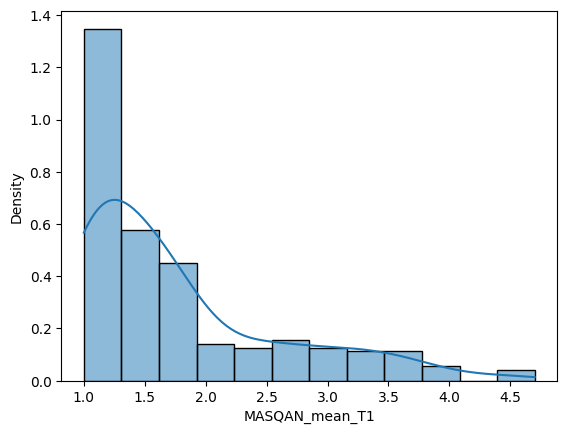

In [ ]:
sns.histplot(df['MASQAN_mean_T1'].dropna(), kde=True, stat="density")

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

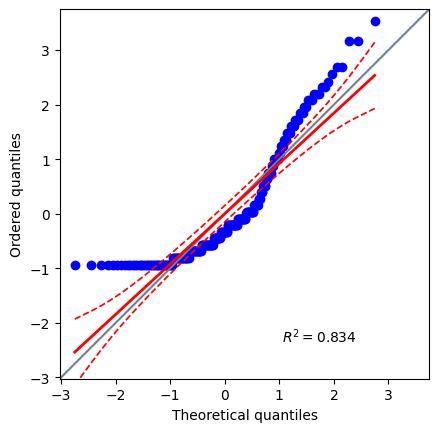

In [ ]:
import pingouin as pg
pg.qqplot(df['MASQAN_mean_T1'], dist = 'norm')

In [ ]:
if p_value < 0.05:
    print(f"Conclusion: p-value = {p_value} => as p-value < 0.05, H1 is accepted => the distribution is significantly different from normal")
else:
    print(f"Conclusion: p-value = {p_value} => as p-value > 0.05, H1 is rejected => the distribution is not significantly different from normal")

Conclusion: p-value = 1.209010655294688e-07 => as p-value < 0.05, H1 is accepted => the distribution is significantly different from normal


### Mann-Whitney test

Since the variable MASQAN_mean_T1 has a non-normal distribution the Mann-Whitney test will be conducted.

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

group1_gender = df[df['Gender'] == 1.0]['MASQAN_mean_T1']
group2_gender = df[df['Gender'] == 2.0]['MASQAN_mean_T1']

stat_gender, p_value_gender = mannwhitneyu(group1_gender.dropna(), group2_gender.dropna(), alternative='two-sided')

print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p_value}")

Mann-Whitney U Test Statistic: 7010.0, p-value: 1.209010655294688e-07


### Conlusion

H0: The mean MASQAN_mean_T1 values for men and women are the same.


H1: The mean MASQAN_mean_T1 values for men and women are different.

p-value < 0.05, H1 is accepted, there are statistically significant differences in the distribution of MASQAN_mean_T1 values between males and females.

## People of different age groups (Age_T1_group)

### Kolmogorov-Smirnov test
Since the sample size for each variable under consideration exceeds 50, the Kolmogorov-Smirnov test will be used to conduct a normality test

In [ ]:
column_name = 'MASQAN_mean_T1'

kstest_result = stats.kstest(df[column_name].dropna(), 'norm', args=(df[column_name].dropna().mean(), df[column_name].dropna().std()))
p_value = kstest_result.pvalue

print(kstest_result)

KstestResult(statistic=0.18828867625839307, pvalue=1.209010655294688e-07, statistic_location=1.8, statistic_sign=1)


<Axes: xlabel='MASQAN_mean_T1', ylabel='Density'>

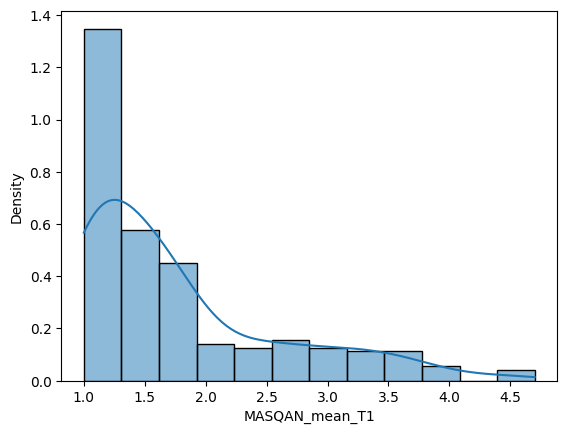

In [ ]:
sns.histplot(df['MASQAN_mean_T1'].dropna(), kde=True, stat="density")

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

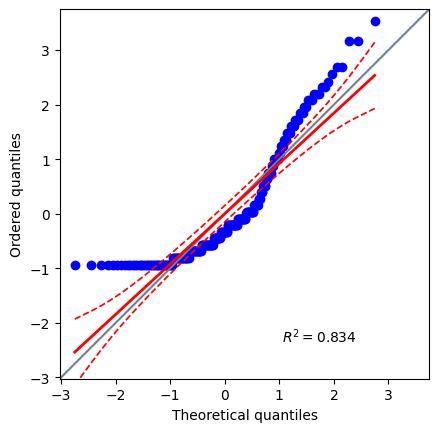

In [ ]:
import pingouin as pg
pg.qqplot(df['MASQAN_mean_T1'], dist = 'norm')

In [ ]:
if p_value < 0.05:
    print(f"Conclusion: p-value = {p_value} => as p-value < 0.05, H1 is accepted => the distribution is significantly different from normal")
else:
    print(f"Conclusion: p-value = {p_value} => as p-value > 0.05, H1 is rejected => the distribution is not significantly different from normal")

Conclusion: p-value = 1.209010655294688e-07 => as p-value < 0.05, H1 is accepted => the distribution is significantly different from normal


### Mann-Whitney test



Since the variable MASQAN_mean_T1 has a non-normal distribution the Mann-Whitney test will be conducted.

In [ ]:
df['Age_Group_40'] = df['Age_T1'].apply(lambda x: '<40' if x < 40 else '>=40')

group_below_40 = df[df['Age_Group_40'] == '<40']['MASQAN_mean_T1'].dropna()
group_40_and_above = df[df['Age_Group_40'] == '>=40']['MASQAN_mean_T1'].dropna()

stat_age, p_value_age = mannwhitneyu(group_below_40, group_40_and_above, alternative='two-sided')

(stat_age, p_value_age)

(297.0, 0.47151311864332446)

### Conlusion

H0: The mean MASQAN_mean_T1 values for people under 40 years of age and 40 years and older are the same. There are no statistically significant differences in the level of anxiety symptomatology between these age groups.

H1: The mean MASQAN_mean_T1 values for people younger than 40 years and 40 years and older are different. There are statistically significant differences in the level of anxiety symptomatology between these age groups.

p-value > 0.05, H1 is rejected, there are no statistically significant differences in the distribution of MASQAN_mean_T1 values between people younger than 40 and those 40 and older.

# Task 3

**Compare the values of the following variables for time points T1 and T4:**
* MASQ_ANH_sum_*
* MASQDG_sum_*

In [ ]:
# MASQ_ANH_sum_*

from scipy.stats import wilcoxon

masq_anh_t1 = df['MASQ_ANH_sum_T1'].dropna()
masq_anh_t4 = df['MASQ_ANH_sum_T4'].dropna()

stat_anh, p_value_anh = wilcoxon(masq_anh_t1, masq_anh_t4)

print(f"Statistic={stat_anh}, p-value={p_value_anh}")

Statistic=6863.5, p-value=1.110101513785955e-06


H0: The mean values of MASQ_ANH_sum at time points T1 and T4 are the same. There are no statistically significant differences between these time points.


H1: The mean MASQ_ANH_sum values at time points T1 and T4 are different. There are statistically significant differences between these time points.

p-value < 0.05, H1 is accepted. There are statistically significant differences in MASQ_ANH_sum values between time points T1 and T4.

In [ ]:
# MASQDG_sum_*

from scipy.stats import wilcoxon

masqdg_sum_t1 = df['MASQDG_sum_T1'].dropna()
masqdg_sum_t4 = df['MASQDG_sum_T4'].dropna()

stat_dg, p_value_dg = wilcoxon(masqdg_sum_t1, masqdg_sum_t4)

print(f"Statistic={stat_dg}, p-value={p_value_dg}")

Statistic=10436.5, p-value=0.6190291376808122


H0: The mean MASQDG_sum values at time points T1 and T4 are the same. There are no statistically significant differences between these time points.

H1: The mean MASQDG_sum values at time points T1 and T4 are different. There are statistically significant differences between these time points.

p-value > 0.05, H1 is rejected. There are no statistically significant differences in MASQDG_sum values between time points T1 and T4.
